In [1]:
import pandas as pd
train = pd.read_csv(r"C:\Users\mpkhd\Desktop\Uni\4th year\Sem1\ST4052\Project1\Advanced\train.csv")
test = pd.read_csv(r"C:\Users\mpkhd\Desktop\Uni\4th year\Sem1\ST4052\Project1\Advanced\test.csv")

In [4]:
X = train.drop(columns = 'HiringDecision')
y = train['HiringDecision']
X_test = test.drop(columns = 'HiringDecision')

In [6]:
from sklearn import tree

clf = tree.DecisionTreeClassifier()
clf = clf.fit(X, y)

In [7]:
yhat = clf.predict(X_test)

In [10]:
from sklearn import metrics
confusion_matrix = metrics.confusion_matrix(test['HiringDecision'], yhat)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])

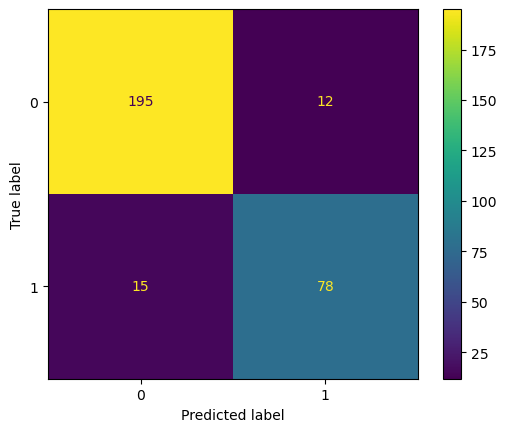

In [12]:
import matplotlib.pyplot as plt
cm_display.plot()
plt.show()

In [14]:
from sklearn.metrics import classification_report

print(classification_report(test['HiringDecision'], yhat))

              precision    recall  f1-score   support

           0       0.93      0.94      0.94       207
           1       0.87      0.84      0.85        93

    accuracy                           0.91       300
   macro avg       0.90      0.89      0.89       300
weighted avg       0.91      0.91      0.91       300



In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc = accuracy_score(test['HiringDecision'], yhat)
prec = precision_score(test['HiringDecision'],yhat, average='weighted')
rec = recall_score(test['HiringDecision'], yhat, average='weighted')
f1 = f1_score(test['HiringDecision'], yhat, average='weighted')

print(f"Accuracy: {acc:.2f}")
print(f"Precision: {prec:.2f}")
print(f"Recall: {rec:.2f}")
print(f"F1 Score: {f1:.2f}")

Accuracy: 0.91
Precision: 0.91
Recall: 0.91
F1 Score: 0.91


In [18]:
X.columns

Index(['Age', 'Gender', 'EducationLevel', 'ExperienceYears',
       'PreviousCompanies', 'DistanceFromCompany', 'InterviewScore',
       'SkillScore', 'PersonalityScore', 'RecruitmentStrategy'],
      dtype='object')

In [20]:
clf.feature_importances_

array([0.03587219, 0.00259727, 0.08291273, 0.14223208, 0.00925648,
       0.03063281, 0.13008493, 0.14278046, 0.09850601, 0.32512505])

In [22]:
clf.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

## Hyperparameter

In [25]:
tree.DecisionTreeClassifier()

DecisionTreeClassifier()

In [43]:
param_space = {'min_samples_leaf': (1,100), 'min_samples_split': (10,30), 'splitter': ['best', 'random']}

In [29]:
from skopt import BayesSearchCV
opt = BayesSearchCV(
    tree.DecisionTreeClassifier(),
    param_space,
    n_iter=32,
    cv=3
)

In [31]:
opt.fit(X, y)

BayesSearchCV(cv=3, estimator=DecisionTreeClassifier(), n_iter=32,
              search_spaces={'min_samples_leaf': (1, 100),
                             'min_samples_split': (10, 30),
                             'splitter': ['best', 'random']})

In [32]:
opt.score(X_test,test['HiringDecision'])

0.9133333333333333

In [37]:
opt.best_params_

OrderedDict([('min_samples_leaf', 7),
             ('min_samples_split', 10),
             ('splitter', 'best')])

In [39]:
best_params = opt.best_params_

best_tree = tree.DecisionTreeClassifier(**best_params)

best_tree.fit(X, y)

best_treevals = best_tree.predict(X_test)

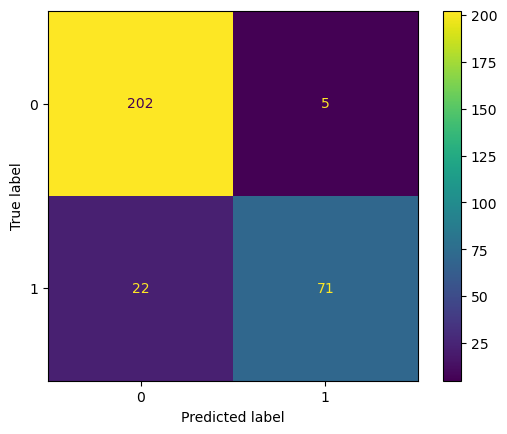

In [41]:
confusion_matrix = metrics.confusion_matrix(test['HiringDecision'], best_treevals)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])
cm_display.plot()
plt.show()